# Sprawozdanie 3

### Piotr Kardyński grupa 3

### Wczytanie bibliotek oraz plików

In [1]:
from analis import print_dataset_stats, check_class_distribution, print_summary_table, set_seed, run_eda, dow
from graph import plot_confusion_matrix_heatmap, plot_series_results, show_misclassified_images, visualize_random_samples
from class_cifar10 import get_cifar10_loaders, get_device, initialize_model
from engine import evaluate_best_model, run_experiment, compare_hardware_speed, execute_series
import torch.optim as optim
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

Ustawienie seed by wyniki przy kazdym odpaleniu były takie same

In [2]:
set_seed1=42  
set_seed(seed=set_seed1) 
# funkcja set_seed ustawia kolejno
# random.seed(seed)
# np.random.seed(seed)
# torch.manual_seed(seed)
# torch.cuda.manual_seed(seed)
# torch.cuda.manual_seed_all(seed)
# torch.backends.cudnn.deterministic = True
# torch.backends.cudnn.benchmark = False

Ustawiono ziarno losowości: 42


Następnie pobieramy dane i wypisujemy czy kod bedzie wykonywac sie na GPU czy CPU odrazu sprawdzamy róznice szybkosci na 3 epokach po 2 razy na róznych "batch_size" by zobaczyc na czym polega różnica:

In [3]:
device = get_device()
ts,vs = dow()
base_cfg = {
    "batch_size": 64, "lr": 0.001, "epochs": 1,
    "hidden_layers": [128, 128], "dropout": 0.0, "optimizer_type": "adam"
}
compare_hardware_speed(device, base_cfg)
base_cfg = {
    "batch_size": 1024, "lr": 0.001, "epochs": 1,
    "hidden_layers": [2048, 2048], "dropout": 0.0, "optimizer_type": "adam"
}
compare_hardware_speed(device, base_cfg)


Wykorzystywane urządzenie: CUDA (NVIDIA GeForce RTX 4050 Laptop GPU)

Files already downloaded and verified


c:\Users\piotr\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified

TEST PORÓWNAWCZY: CPU vs CUDA (1 Epoki)
Rozpoczynam test na: cuda
E1 Val Acc: 46.51% | Val Loss: 1.5087

Rozpoczynam test na: CPU
E1 Val Acc: 46.69% | Val Loss: 1.5072

CZAS CUDA: 15.83 sekundy
CZAS CPU : 14.75 sekundy
CUDA jest szybsze o: 0.9x

TEST PORÓWNAWCZY: CPU vs CUDA (1 Epoki)
Rozpoczynam test na: cuda
E1 Val Acc: 46.19% | Val Loss: 1.5212

Rozpoczynam test na: CPU
E1 Val Acc: 46.93% | Val Loss: 1.5241

CZAS CUDA: 15.26 sekundy
CZAS CPU : 27.03 sekundy
CUDA jest szybsze o: 1.8x


Widać róznice szybkosci Cuda i CPU szczegulnie w drugim porównaniu gdy "batch_size" jest wiekszy. Spowodowane to jest tym ze karta graficzna moze przerobic wiecej na raz a cpu musi to robic po kolei. Przy małych paczkach danych jest mała - wręcz odrworna - różnica ponieważ karta graficzna dłużej "czeka" na dane niż je liczy wiec cpu ją "przegania".

### Statystyki
Sprawdzenie statystyk, podzielenie zbioru na treningowy i validacyjny. Sprawdzenie jak wygladają klasy oraz pokazanie przykładowych obrazów.

Files already downloaded and verified
Files already downloaded and verified
--- Dataset Statistics ---
Total training images: 50000
Total test images: 10000
Single image dimensions: (32, 32, 3) (H x W x C)
Pixel value range: min = 0, max = 255

--- Class Distribution ---
Total images per class (Train + Test):
 - Class 'airplane': 6000 images
 - Class 'automobile': 6000 images
 - Class 'bird': 6000 images
 - Class 'cat': 6000 images
 - Class 'deer': 6000 images
 - Class 'dog': 6000 images
 - Class 'frog': 6000 images
 - Class 'horse': 6000 images
 - Class 'ship': 6000 images
 - Class 'truck': 6000 images

--- Visualizing 10 Sample Images ---


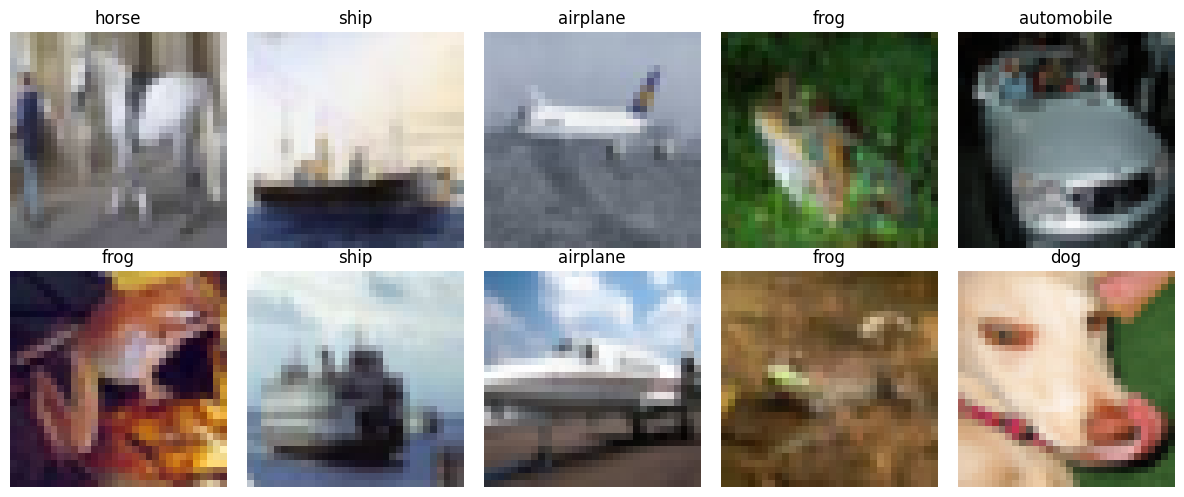

In [4]:
run_eda(set_seed1)

Rozmiar obrazu to 32x32x3=3072. Wiedząc to ze obrazków treningowych jest 50000 to - jesli weźmiemy mały batch np. 32 Sieć wykona aż (50000/32=) 1562 aktualizacje wag w jednej epoce. Trening będzie trwał długo, ale będzie bardzo precyzyjny.
Jeśli duży batch (np. 256): Sieć wykona tylko 195 aktualizacji. Trening będzie szybszy, ale sieć dostanie mniej „lekcji” w jednej epoce.
Najlepiej wybrac cos pośrodku zeby karta działała choc troszke szybciej niz cpu a jednak by trening był dokładny.

In [5]:
base_cfg = {
        "batch_size": 256, "lr": 0.001, "epochs": 7,
        "hidden_layers": [512, 128], "dropout": 0.0, "optimizer_type": "adam"
    }

Przeprowadźmy test prędkości:

In [6]:
compare_hardware_speed(device, base_cfg)


TEST PORÓWNAWCZY: CPU vs CUDA (1 Epoki)
Rozpoczynam test na: cuda
E1 Val Acc: 48.53% | Val Loss: 1.4815

Rozpoczynam test na: CPU
E1 Val Acc: 47.44% | Val Loss: 1.4910

CZAS CUDA: 15.68 sekundy
CZAS CPU : 16.46 sekundy
CUDA jest szybsze o: 1.1x


Test pokazuje ze czasy sa podobne.

### Eksperymenty:

Learning rate:


>>> TEST SERII: lr = 0.0001
E1 Val Acc: 43.17% | Val Loss: 1.6323
E2 Val Acc: 45.94% | Val Loss: 1.5399
E3 Val Acc: 48.62% | Val Loss: 1.4798
E4 Val Acc: 49.75% | Val Loss: 1.4375
E5 Val Acc: 50.74% | Val Loss: 1.4109
E6 Val Acc: 51.71% | Val Loss: 1.3856
E7 Val Acc: 51.58% | Val Loss: 1.3751

>>> TEST SERII: lr = 0.001
E1 Val Acc: 48.04% | Val Loss: 1.4941
E2 Val Acc: 50.76% | Val Loss: 1.4025
E3 Val Acc: 52.05% | Val Loss: 1.3782
E4 Val Acc: 53.10% | Val Loss: 1.3546
E5 Val Acc: 52.97% | Val Loss: 1.3503
E6 Val Acc: 53.92% | Val Loss: 1.3388
E7 Val Acc: 53.83% | Val Loss: 1.3638

>>> TEST SERII: lr = 0.01
E1 Val Acc: 38.16% | Val Loss: 1.7323
E2 Val Acc: 42.50% | Val Loss: 1.6254
E3 Val Acc: 41.81% | Val Loss: 1.6755
E4 Val Acc: 42.89% | Val Loss: 1.6406
E5 Val Acc: 40.65% | Val Loss: 1.6426
E6 Val Acc: 43.23% | Val Loss: 1.6255
E7 Val Acc: 43.16% | Val Loss: 1.6395

TABELA WYNIKÓW: Wpływ parametru 'Learning Rate'
Learning Rate   | Końcowe Accuracy | Końcowy Loss
-------------------

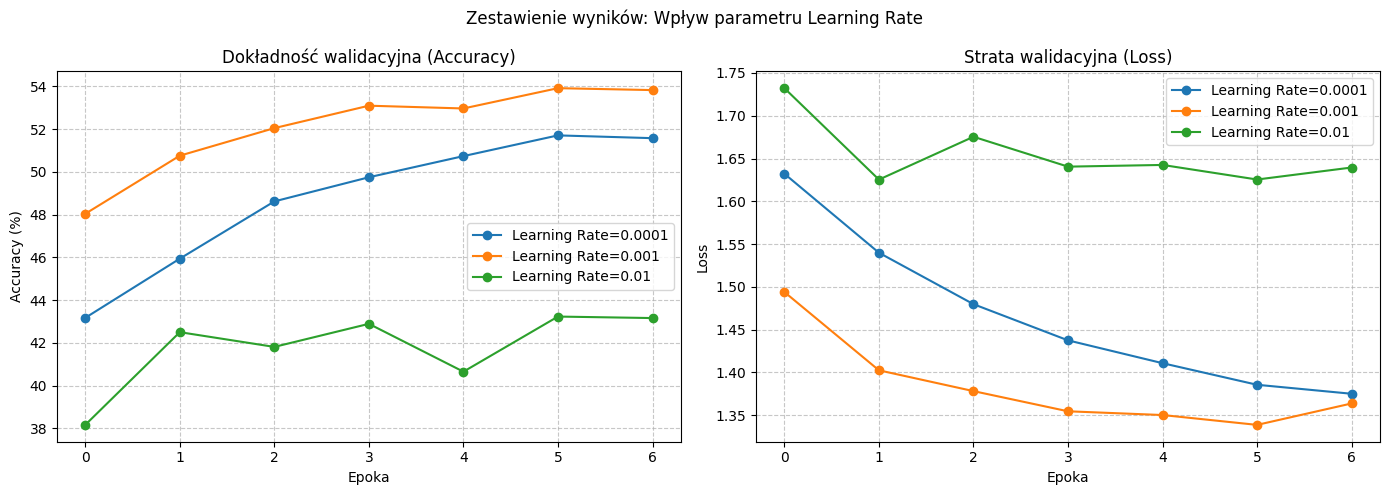

In [7]:
res_lr = execute_series(device, base_cfg, "lr", [0.0001, 0.001, 0.01])
print_summary_table(res_lr, "Learning Rate")
plot_series_results(res_lr, "Learning Rate")

I wyższa dokładność tym lepiej tak samo jak niższa stata.

Learning Rate   | Końcowe Accuracy | Końcowy Loss
- 0.0001          |           51.58% |       1.3751
- 0.001           |           53.83% |       1.3638
- 0.01            |           43.16% |       1.6395


widac ze na 7 epokach najlepiej radzi sobie lr=0.001 jednak pod koniec wykresu strata walidacyjna idzie do gory

Co moża zorbic:
- Przy 15 epokach linia pomarańczowa mogłaby już mocno „odjechać” (Loss poszedłby w górę), bo model zacząłby za mocno skupiać się na detalach treningowych.Wniosek: Przy 5-7 epokach wygrywa, ale przy 15 epokach wymagałaby Dropoutu lub mniejszego współczynnika uczenia pod koniec.
- Linia niebieska jest bardzo stabilna. Ponieważ robi małe kroki, rzadziej „przestrzeliwuje” i rzadziej wpada w gwałtowny overfitting wiec po 15 epokach mogłaby osiągnąć np. 54-55 ac i mieć niższy, stabilniejszy Loss niż linia pomarańczowa

Wybiore lr=0.0001 oraz wiecej epok.


Batch size:


>>> TEST SERII: batch_size = 32
E1 Val Acc: 46.60% | Val Loss: 1.5021
E2 Val Acc: 50.21% | Val Loss: 1.4117
E3 Val Acc: 51.63% | Val Loss: 1.3638
E4 Val Acc: 52.62% | Val Loss: 1.3535
E5 Val Acc: 53.67% | Val Loss: 1.3307
E6 Val Acc: 53.92% | Val Loss: 1.3506
E7 Val Acc: 53.24% | Val Loss: 1.3676

>>> TEST SERII: batch_size = 64
E1 Val Acc: 47.16% | Val Loss: 1.4853
E2 Val Acc: 50.62% | Val Loss: 1.4002
E3 Val Acc: 51.98% | Val Loss: 1.3621
E4 Val Acc: 53.46% | Val Loss: 1.3483
E5 Val Acc: 53.60% | Val Loss: 1.3315
E6 Val Acc: 54.84% | Val Loss: 1.3170
E7 Val Acc: 54.13% | Val Loss: 1.3780

>>> TEST SERII: batch_size = 128
E1 Val Acc: 47.01% | Val Loss: 1.4977
E2 Val Acc: 50.57% | Val Loss: 1.3905
E3 Val Acc: 52.48% | Val Loss: 1.3536
E4 Val Acc: 53.91% | Val Loss: 1.3343
E5 Val Acc: 53.07% | Val Loss: 1.3410
E6 Val Acc: 54.56% | Val Loss: 1.3320
E7 Val Acc: 54.96% | Val Loss: 1.3425

TABELA WYNIKÓW: Wpływ parametru 'Batch Size'
Batch Size      | Końcowe Accuracy | Końcowy Loss
------

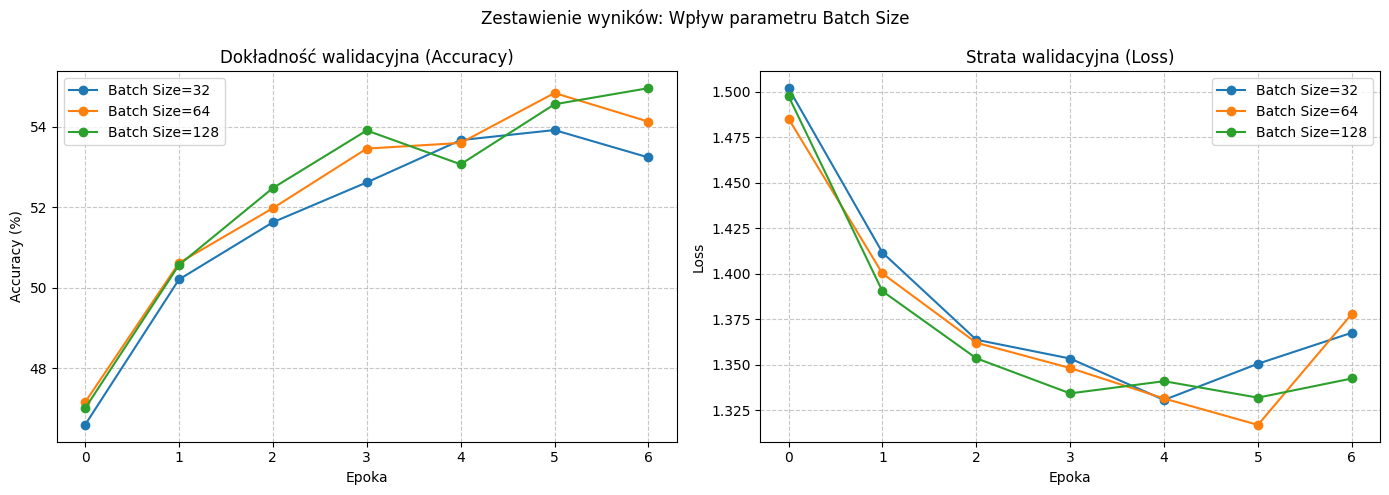

In [8]:
res_bs = execute_series(device, base_cfg, "batch_size", [32, 64, 128])
print_summary_table(res_bs, "Batch Size")
plot_series_results(res_bs, "Batch Size")

Z wykrsów można zauważyc, że batch 64 prawdopodobnie sie przetrenował bo w epoce 5 wynik był naprawde dobry lecz pózniej model zacza dopasowywac sie do niewłasciwych danych. Dla batch 32 model jest w pewnym sensie nerwowy przez co mocno skacze i na koniec maleje. Batch 128 jest najbardziej stabilny bo model dostaje wieceje informacji na raz przez co moze usrednic wynik.

Wybiore batch 128 do kolejnej czesci zadania

Dropout:


>>> TEST SERII: dropout = 0.0
E1 Val Acc: 47.49% | Val Loss: 1.4938
E2 Val Acc: 50.88% | Val Loss: 1.4016
E3 Val Acc: 51.46% | Val Loss: 1.3781
E4 Val Acc: 53.40% | Val Loss: 1.3367
E5 Val Acc: 53.66% | Val Loss: 1.3321
E6 Val Acc: 54.21% | Val Loss: 1.3227
E7 Val Acc: 54.32% | Val Loss: 1.3635

>>> TEST SERII: dropout = 0.2
E1 Val Acc: 46.71% | Val Loss: 1.5188
E2 Val Acc: 49.60% | Val Loss: 1.4417
E3 Val Acc: 50.74% | Val Loss: 1.3892
E4 Val Acc: 52.16% | Val Loss: 1.3633
E5 Val Acc: 52.77% | Val Loss: 1.3445
E6 Val Acc: 54.03% | Val Loss: 1.3192
E7 Val Acc: 53.99% | Val Loss: 1.3124

>>> TEST SERII: dropout = 0.5
E1 Val Acc: 43.12% | Val Loss: 1.6270
E2 Val Acc: 46.15% | Val Loss: 1.5547
E3 Val Acc: 47.33% | Val Loss: 1.5068
E4 Val Acc: 49.00% | Val Loss: 1.4848
E5 Val Acc: 49.46% | Val Loss: 1.4571
E6 Val Acc: 49.38% | Val Loss: 1.4348
E7 Val Acc: 50.06% | Val Loss: 1.4257

TABELA WYNIKÓW: Wpływ parametru 'Dropout'
Dropout         | Końcowe Accuracy | Końcowy Loss
----------------

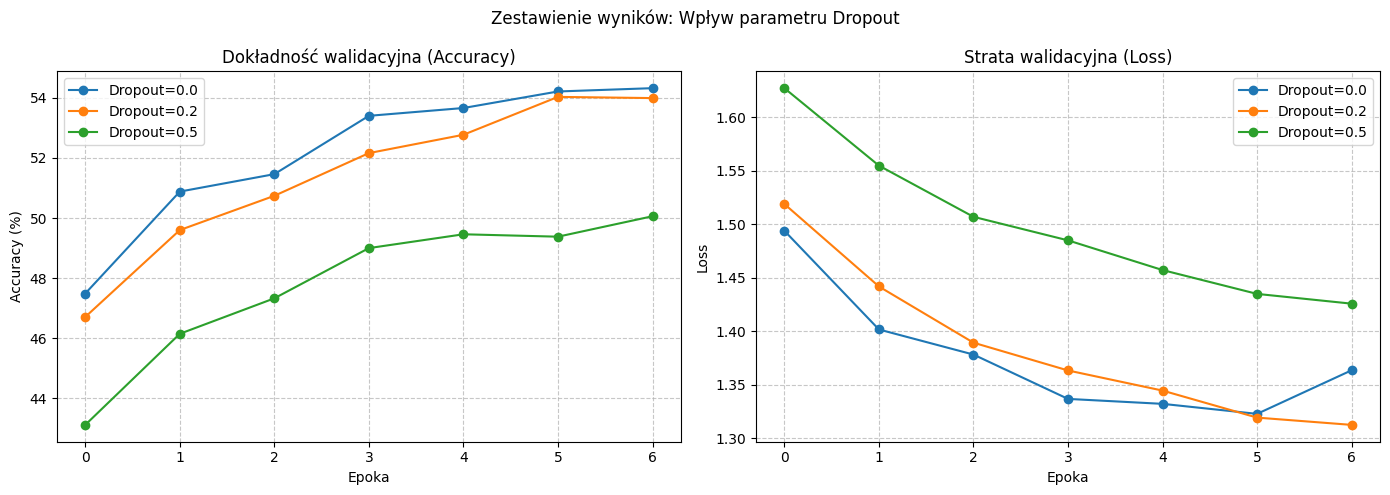

In [9]:
res_dr = execute_series(device, base_cfg, "dropout", [0.0, 0.2, 0.5])
print_summary_table(res_dr, "Dropout")
plot_series_results(res_dr, "Dropout")

Mamy do wyboru dropout 0.2 oraz 0.0 poniewaz maja najwyzszą dokładność orazn najniższą stratę.
Najlepiej wybrac linie pomarańczową ponieważ linia loss ciagle spada i model nie wykuwa na pamiec tak jak 0.0 (widac to na końcu wykresu loss)

Optymalizatory:


>>> TEST SERII: optimizer_type = adam
E1 Val Acc: 46.83% | Val Loss: 1.4967
E2 Val Acc: 50.77% | Val Loss: 1.4027
E3 Val Acc: 50.93% | Val Loss: 1.3907
E4 Val Acc: 52.21% | Val Loss: 1.3653
E5 Val Acc: 53.18% | Val Loss: 1.3432
E6 Val Acc: 54.09% | Val Loss: 1.3489
E7 Val Acc: 54.39% | Val Loss: 1.3492

>>> TEST SERII: optimizer_type = sgd
E1 Val Acc: 11.23% | Val Loss: 2.2890
E2 Val Acc: 16.93% | Val Loss: 2.2760
E3 Val Acc: 21.28% | Val Loss: 2.2633
E4 Val Acc: 24.13% | Val Loss: 2.2503
E5 Val Acc: 25.60% | Val Loss: 2.2364
E6 Val Acc: 26.44% | Val Loss: 2.2213
E7 Val Acc: 26.99% | Val Loss: 2.2053

TABELA WYNIKÓW: Wpływ parametru 'Optimizer'
Optimizer       | Końcowe Accuracy | Końcowy Loss
--------------------------------------------------
adam            |           54.39% |       1.3492
sgd             |           26.99% |       2.2053
--------------------------------------------------


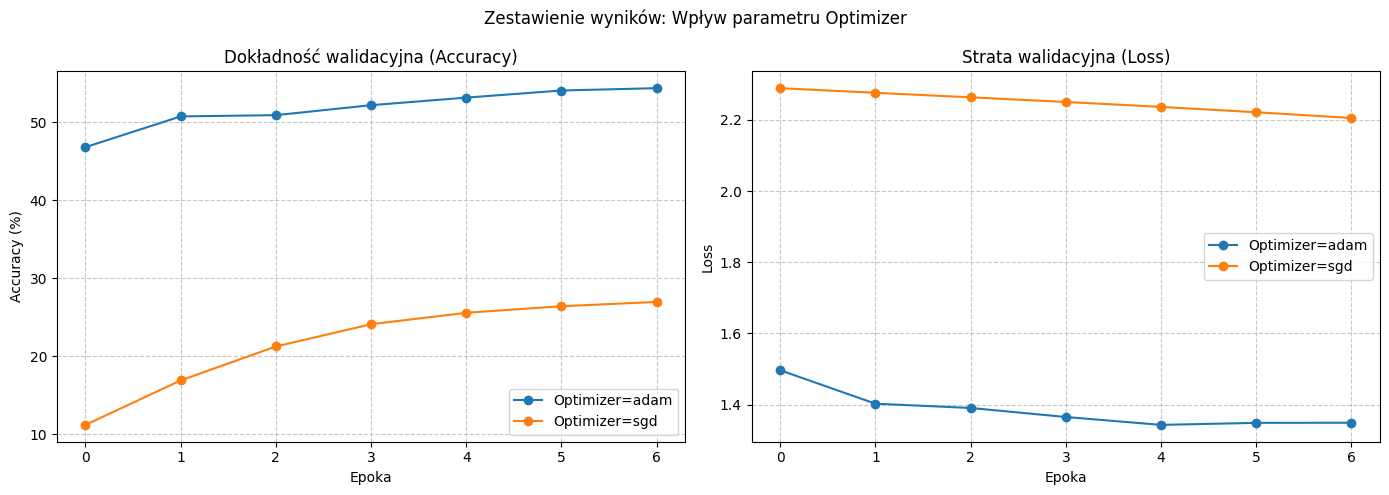

In [10]:
res_opt = execute_series(device, base_cfg, "optimizer_type", ["adam", "sgd"])
print_summary_table(res_opt, "Optimizer")
plot_series_results(res_opt, "Optimizer")

Bezkonkurencyjnie wygrywa adam - sgd wymaga znacznie więcej epok (np setek) oraz bardzo precyzyjnego ustawienia parametrów, aby dogonić Adama.

Wpływ liczby neuronów (Architektura)


Eksperyment: Architektura sieci (liczba neuronów)

>>> TEST SERII: hidden_layers = [64, 64]
E1 Val Acc: 45.33% | Val Loss: 1.5617
E2 Val Acc: 47.44% | Val Loss: 1.4988
E3 Val Acc: 48.60% | Val Loss: 1.4548
E4 Val Acc: 49.04% | Val Loss: 1.4476
E5 Val Acc: 49.89% | Val Loss: 1.4271
E6 Val Acc: 50.33% | Val Loss: 1.4017
E7 Val Acc: 51.00% | Val Loss: 1.3838

>>> TEST SERII: hidden_layers = [256, 128]
E1 Val Acc: 46.48% | Val Loss: 1.5232
E2 Val Acc: 49.54% | Val Loss: 1.4329
E3 Val Acc: 50.88% | Val Loss: 1.3902
E4 Val Acc: 52.31% | Val Loss: 1.3617
E5 Val Acc: 53.33% | Val Loss: 1.3438
E6 Val Acc: 53.80% | Val Loss: 1.3406
E7 Val Acc: 53.46% | Val Loss: 1.3964

>>> TEST SERII: hidden_layers = [512, 256, 128]
E1 Val Acc: 47.59% | Val Loss: 1.4950
E2 Val Acc: 50.53% | Val Loss: 1.4008
E3 Val Acc: 51.91% | Val Loss: 1.3700
E4 Val Acc: 53.70% | Val Loss: 1.3232
E5 Val Acc: 53.51% | Val Loss: 1.3401
E6 Val Acc: 54.82% | Val Loss: 1.3252
E7 Val Acc: 54.90% | Val Loss: 1.3539

>>> TEST SERII:

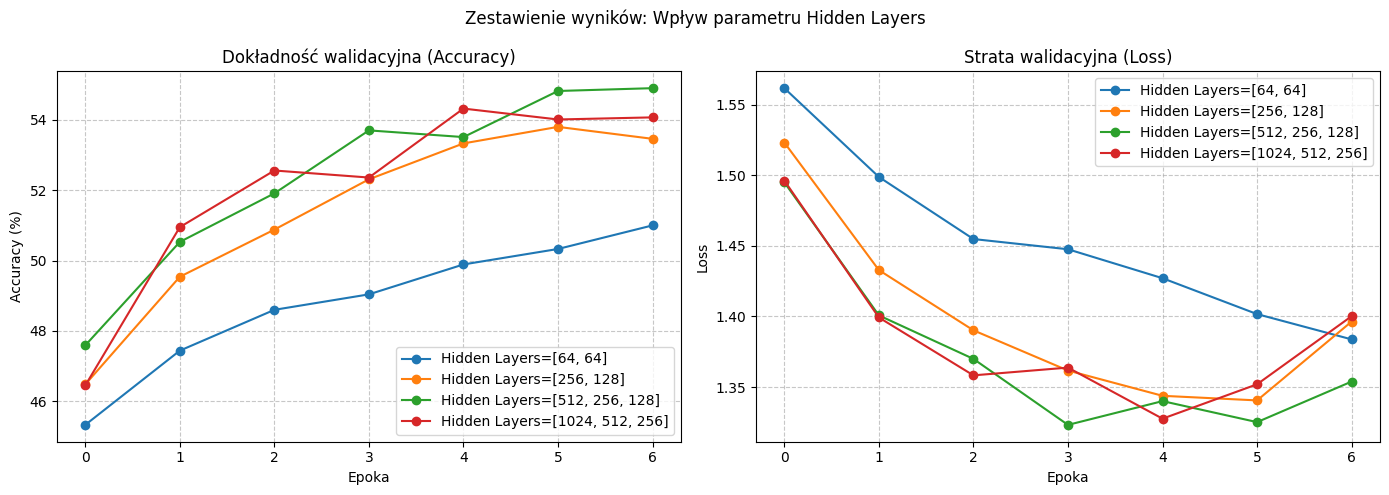

In [11]:
print("\nEksperyment: Architektura sieci (liczba neuronów)")
res_layers = execute_series(device, base_cfg, "hidden_layers", [
    [64, 64],                   # Bardzo mała sieć
    [256, 128],                 # Średnia sieć
    [512, 256, 128],            # Duża sieć
    [1024, 512, 256]            # Bardzo duża sieć
])
print_summary_table(res_layers, "Hidden Layers")
plot_series_results(res_layers, "Hidden Layers")

Zauważyłem że większe sieci (np. [256, 128] oraz [512, 256, 128]) wykazują wzrost błędu walidacyjnego w końcowych epokach, jest to wczesnym symptomem przetrenowania. Rozważyłem redukcję liczby neuronów do architektury [128, 64] w celu ustabilizowania modelu lecz ostatecznie zdecydowałęm się zachować większą pojemność sieci [512, 256, 128], planując zniwelować skok funkcji straty poprzez zastosowanie wyznaczonego wczesniej Dropout (0.2) w modelu finalnym, jednak zanim to zrobię sprawdze jeszcze model który ma hidden layers "posrodku" i jest złożony z poteng 3 - [384, 192, 96], choć pewnie będzie "głupszy" bedzie on bardziej odporny na szum i powinien sie ustabilizować.


Eksperyment: Architektura sieci (liczba neuronów)

>>> TEST SERII: hidden_layers = [384, 192, 96]
E1 Val Acc: 46.56% | Val Loss: 1.5066
E2 Val Acc: 49.94% | Val Loss: 1.4251
E3 Val Acc: 50.26% | Val Loss: 1.4228
E4 Val Acc: 52.75% | Val Loss: 1.3409
E5 Val Acc: 53.27% | Val Loss: 1.3373
E6 Val Acc: 53.91% | Val Loss: 1.3415
E7 Val Acc: 53.02% | Val Loss: 1.3533

TABELA WYNIKÓW: Wpływ parametru 'Hidden Layers'
Hidden Layers   | Końcowe Accuracy | Końcowy Loss
--------------------------------------------------
[384, 192, 96]  |           53.02% |       1.3533
--------------------------------------------------


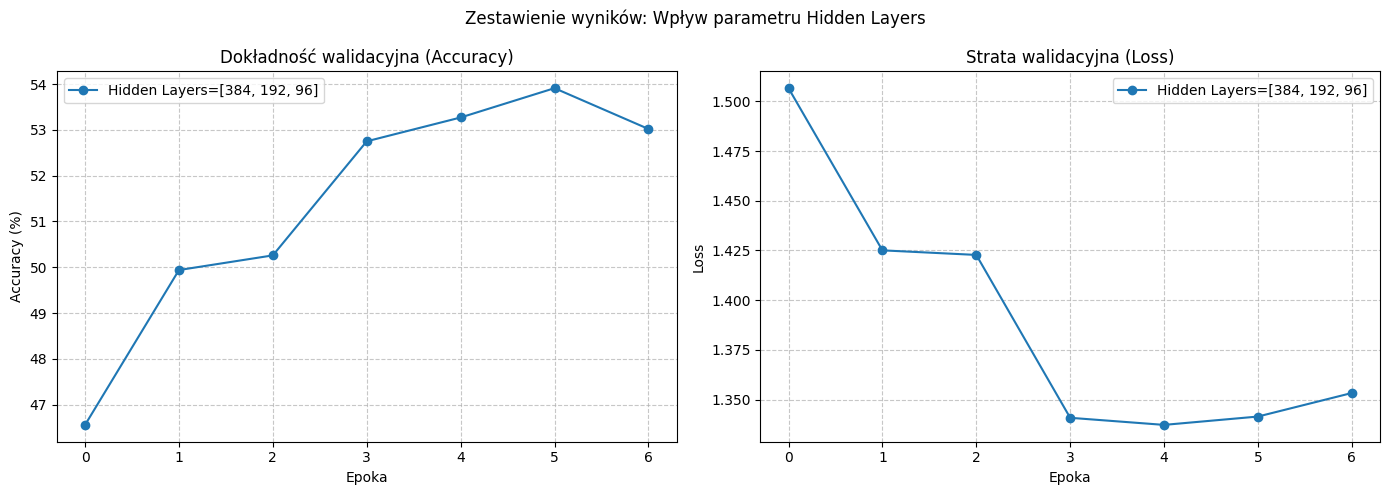

In [12]:
print("\nEksperyment: Architektura sieci (liczba neuronów)")
res_layers = execute_series(device, base_cfg, "hidden_layers", [
    [384, 192, 96]
])
print_summary_table(res_layers, "Hidden Layers")
plot_series_results(res_layers, "Hidden Layers")

### Najlepszy model

TRENOWANIE NAJLEPSZEGO MODELU (Parametry wybrane z testów)
E1 Val Acc: 42.72% | Val Loss: 1.6362
E2 Val Acc: 46.31% | Val Loss: 1.5372
E3 Val Acc: 48.33% | Val Loss: 1.4700
E4 Val Acc: 49.70% | Val Loss: 1.4259
E5 Val Acc: 50.95% | Val Loss: 1.3931
E6 Val Acc: 51.97% | Val Loss: 1.3681
E7 Val Acc: 52.54% | Val Loss: 1.3487
E8 Val Acc: 53.62% | Val Loss: 1.3243
E9 Val Acc: 53.60% | Val Loss: 1.3174
E10 Val Acc: 53.96% | Val Loss: 1.3055
E11 Val Acc: 54.60% | Val Loss: 1.2906
E12 Val Acc: 54.91% | Val Loss: 1.2848
E13 Val Acc: 55.58% | Val Loss: 1.2641
E14 Val Acc: 55.51% | Val Loss: 1.2637
E15 Val Acc: 55.56% | Val Loss: 1.2632
E16 Val Acc: 55.32% | Val Loss: 1.2686
E17 Val Acc: 56.32% | Val Loss: 1.2429

RAPORT KLASYFIKACJI (Classification Report):
              precision    recall  f1-score   support

    airplane       0.62      0.66      0.64      1000
  automobile       0.66      0.69      0.67      1000
        bird       0.48      0.42      0.45      1000
         cat       0.40 

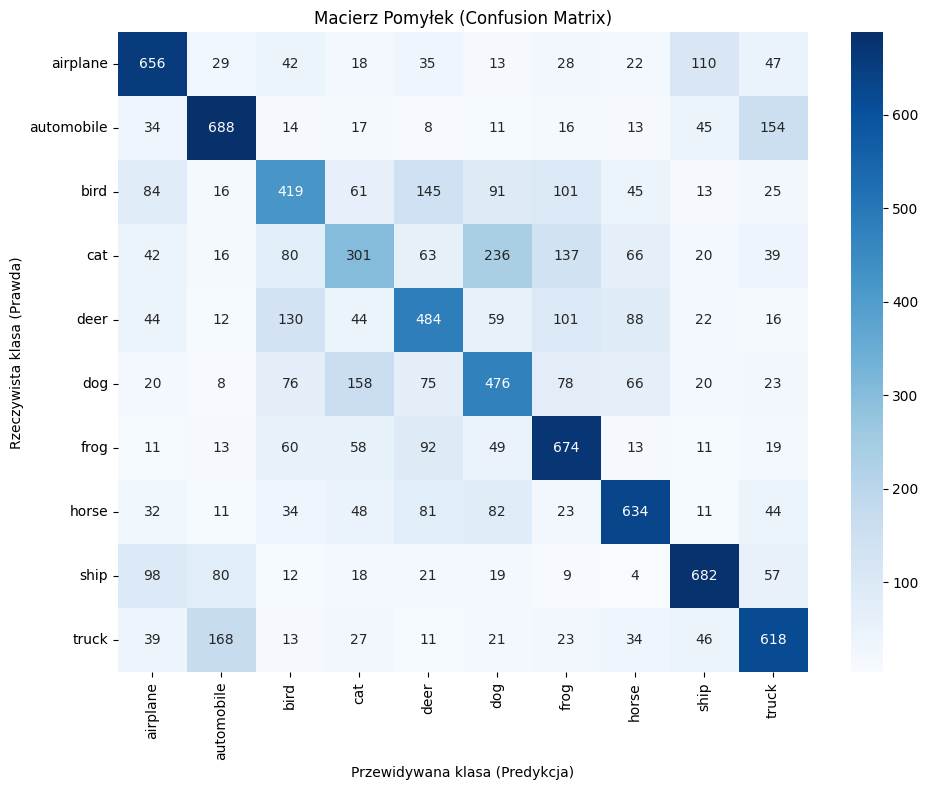

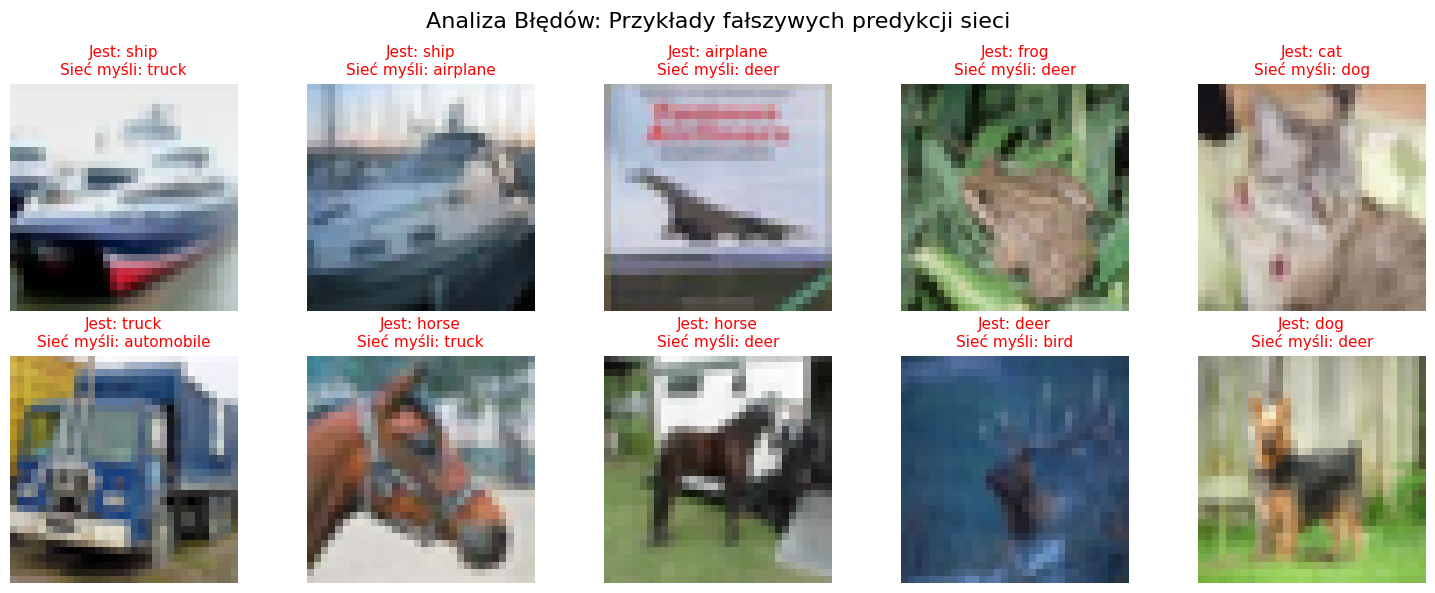

In [13]:
print("TRENOWANIE NAJLEPSZEGO MODELU (Parametry wybrane z testów)")
best_cfg = {
        "batch_size": 128, "lr": 0.0001, "epochs": 17,
        "hidden_layers": [512, 256, 128], "dropout": 0.2, "optimizer_type": "adam"
    }
tr, te = get_cifar10_loaders(batch_size=best_cfg["batch_size"])
history, best_model = run_experiment(device, best_cfg, tr, te)
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
y_true, y_pred, misclassified = evaluate_best_model(best_model, te, device, classes)

plot_confusion_matrix_heatmap(y_true, y_pred, classes)
show_misclassified_images(misclassified, classes)

W:
E13 Val Acc: 55.58% | Val Loss: 1.2641
E14 Val Acc: 55.51% | Val Loss: 1.2637

było chwilowe załamanie trendu (spadek Accuracy o 0.1 p.p. oraz wzrost Loss), dropout pomógł modelowi wygrzebac się z dołka.

widać że model przy 30-40 epokach powoli doszedłby do wartości około 60%

### Sprawdzenie innego proponowanego modelu wczesniej
"Mądre" wybranie argumentów które były 2 w kolejności do "najlepszego" plus użycie lr_scheduler.ReduceLROnPlateau

by to zrobic nalezy wyedytowac metody z dołaczonych plików i połaczyc je w jedną całość (pomagał mi w wym bardzo gemnini 3 pro)


Wykorzystywane urządzenie: CUDA (NVIDIA GeForce RTX 4050 Laptop GPU)



c:\Users\piotr\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Rozpoczynanie treningu na cuda...
E[1/20] Acc: 44.94% | V-Loss: 1.5585 | LR: 0.001
E[2/20] Acc: 49.02% | V-Loss: 1.4444 | LR: 0.001
E[3/20] Acc: 50.76% | V-Loss: 1.4021 | LR: 0.001
E[4/20] Acc: 52.41% | V-Loss: 1.3816 | LR: 0.001
E[5/20] Acc: 51.82% | V-Loss: 1.3626 | LR: 0.001
E[6/20] Acc: 52.43% | V-Loss: 1.3367 | LR: 0.001
E[7/20] Acc: 52.20% | V-Loss: 1.3433 | LR: 0.001
E[8/20] Acc: 53.64% | V-Loss: 1.3350 | LR: 0.001
E[9/20] Acc: 54.00% | V-Loss: 1.3084 | LR: 0.001
E[10/20] Acc: 54.92% | V-Loss: 1.3056 | LR: 0.001
E[11/20] Acc: 55.04% | V-Loss: 1.3129 | LR: 0.001
E[12/20] Acc: 55.36% | V-Loss: 1.3098 | LR: 0.001
E[13/20] Acc: 54.72% | V-Loss: 1.3079 | LR: 0.0005
E[14/20] Acc: 56.55% | V-Loss: 1.2936 | LR: 0.0005
E[15/20] Acc: 57.07% | V-Loss: 1.2982 | LR: 0.0005
E[16/20] Acc: 56.98% | V-Loss: 1.2926 | LR: 0.0005
E[17/20] Acc: 56.83% | V-Loss: 1.3005 | LR: 0.0005
E[18/20] Acc: 57.20% | V-Loss: 1.3103 | LR: 0.0005
E[19/20] Acc: 57.04% | V-Loss: 1.3190 | LR: 0.00025
E[20/20] Acc: 57.

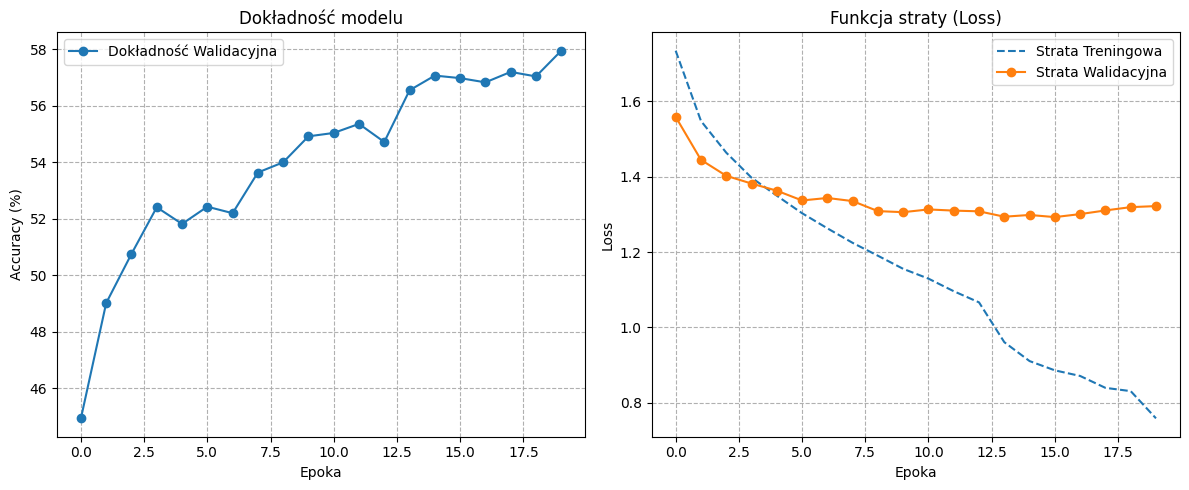

In [ ]:
def train_final_model():
    device = get_device()
    train_loader, test_loader = get_cifar10_loaders(batch_size=128)
    
    model = initialize_model(
        device=device, 
        hidden_sizes=[512, 256, 128], 
        dropout_rate=0.2
    )

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

    history = {
        'train_loss': [],
        'val_loss': [],
        'val_acc': []
    }

    epochs = 20
    print(f"Rozpoczynanie treningu na {device}...")

    for epoch in range(epochs):
        # --- TRENING ---
        model.train()
        total_train_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

        # --- WALIDACJA ---
        model.eval()
        total_val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                total_val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        # Obliczanie średnich
        avg_train_loss = total_train_loss / len(train_loader)
        avg_val_loss = total_val_loss / len(test_loader)
        val_acc = 100 * correct / total

        # Zapisywanie do historii
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_acc)

        # Aktualizacja Schedulera
        scheduler.step(avg_val_loss)
        
        current_lr = optimizer.param_groups[0]['lr']
        print(f"E[{epoch+1}/{epochs}] Acc: {val_acc:.2f}% | V-Loss: {avg_val_loss:.4f} | LR: {current_lr}")

    plt.figure(figsize=(12, 5))

    # Wykres Dokładności (Accuracy)
    plt.subplot(1, 2, 1)
    plt.plot(history['val_acc'], label='Dokładność Walidacyjna', marker='o')
    plt.title('Dokładność modelu')
    plt.xlabel('Epoka')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True, linestyle='--')

    # Wykres Straty (Loss)
    plt.subplot(1, 2, 2)
    plt.plot(history['train_loss'], label='Strata Treningowa', linestyle='--')
    plt.plot(history['val_loss'], label='Strata Walidacyjna', marker='o')
    plt.title('Funkcja straty (Loss)')
    plt.xlabel('Epoka')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--')

    plt.tight_layout()
    plt.show()
train_final_model()

### Działanie kodu oraz wnioski
Kod:
ReduceLROnPlateau działa na zasadzie inteligentnego hamulca który zamiast sztyno zmiejszac tępo nauki obserwuje stratę walidacyjną a kiedy model przestaje robić postepy dopiero reaguje.
- mode='min': Scheduler pilnuje, aby V-Loss malał. Jeśli przestanie maleć, uznaje to za zastój
- W epokach 11 i 12 V-Loss wynosił kolejno 1.3129 i 1.3098 (brak znaczącej poprawy względem epoki 10, gdzie było 1.3056). Dlatego w E13 widzimy spadek LR z 0.001 na 0.0005

Wnioski:
Mimo świetnego wyniku na końcu wykres po prawej (Loss) pokazuje niepokojący trend, wartosci pomału wzrastają od epoki 16. Model zaczyna coraz lepiej "zapamiętywać" bazę treningową, ale jego realna pewność siebie na nowych danych (walidacyjnych) powoli maleje

Najlepszy "moment" modelu to okolice 16. epoki – tam V-Loss był najniższy (1.2926), a dokładność była już bardzo wysoka (56.98%). To jest punkt, w którym model ma najlepszą zdolność generalizacji. Wynik z 20. epoki jest wyższy, ale okupiony większym błędem (Loss)

Model w porównaniu do poprzedniego usykał
poprzedni E17 Val Acc: 56.32% | Val Loss: 1.2429
ten model E[17/20] Acc: 56.83% | V-Loss: 1.3005 | LR: 0.0005
czyli w epoce 17 jest gorszy. Obecny model częściej "trafia", ale gdy się myli, robi to z mniejszą pewnością lub popełnia drastyczniejsze błędy.